In [139]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from pathlib import Path

In [186]:
duration_sec = 200
sfreq = 207

def pink_noise(n, alpha=1.0, rng=None):
    """Generate approximate 1/f^alpha noise using frequency-domain shaping."""
    rng = np.random.default_rng(rng)
    freqs = np.fft.rfftfreq(n, d=1.0)
    spectrum = rng.normal(size=len(freqs)) + 1j * rng.normal(size=len(freqs))

    # Avoid divide-by-zero at DC
    scale = np.ones_like(freqs)
    scale[1:] = 1 / (freqs[1:] ** (alpha / 2))

    shaped = spectrum * scale
    x = np.fft.irfft(shaped, n=n)
    x = (x - np.mean(x)) / np.std(x)
    return x

def generate_eeg_like(rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    n = int(duration_sec * sfreq)
    t = np.arange(n) / sfreq

    # Background rhythms
    delta = 20 * np.sin(2 * np.pi * 2.0 * t)
    theta = 10 * np.sin(2 * np.pi * 6.0 * t)
    alpha = 15 * np.sin(2 * np.pi * 10.0 * t)
    beta  = 5  * np.sin(2 * np.pi * 18.0 * t)

    # Colored noise for a more EEG-like background
    noise = 8 * pink_noise(n, alpha=1.2, rng=rng)

    eeg = delta + theta + alpha + beta + noise

    # Add 1 or 2 burst events
    burst_specs = [
        (17, 6, 79),   # start_time_sec, duration_sec, amplitude
        (190, 4, 98),
    ]

    for start, dur, amp in burst_specs:
        if start < duration_sec:
            end = min(start + dur, duration_sec)
            mask = (t >= start) & (t < end)

            # Burst: higher-amplitude rhythmic activity with a bit of noise
            burst = amp * np.sin(2 * np.pi * 13.0 * t[mask]) + 0.5 * amp * np.sin(2 * np.pi * 17.0 * t[mask])
            burst += 3 * rng.normal(size=mask.sum())
            eeg[mask] += burst

    return t, eeg

# Generate signal
t, eeg = generate_eeg_like()

# Remove middle portion (missing recording interval)
missing_sec = [94, 137] * sfreq
eeg[missing_sec[0] * sfreq : missing_sec[1] * sfreq] = np.nan

In [240]:
def make_fig(version: int = 0):
    fig, ax = plt.subplots(figsize=(10, 3))
    # Reserve space at the top for a future legend in every version
    fig.subplots_adjust(top=.87, bottom=.15, left=.08, right=.99)

    ax.plot(t, eeg, linewidth=0.7, color="#394995")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude ($\\mu$V)")
    ax.set_xlim(0, duration_sec)
    missing_middle = (missing_sec[0] + missing_sec[1]) / 2
    ax.xaxis.set_major_locator(MultipleLocator(15))

    if version == 0:
        ax.text(missing_middle, 0, 'recording gap /\nexcluded artifact', ha='center', va='center')

    if version >= 1:
        ax.xaxis.grid(linewidth=1, color='black', alpha=1)

    if version >= 2:
        ax.axvspan(0, 90, color='mediumseagreen', label='existing segment')
        ax.axvspan(90, 150, color='indianred', label='non-existing segment')
        ax.axvspan(150, duration_sec, color='mediumseagreen')
        fig.legend(ncols=2, loc='upper center')

    return fig

# make_fig(1)
# plt.show()

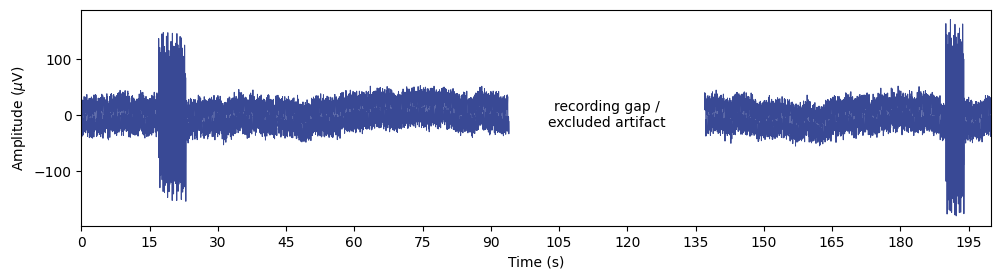

In [241]:
fig0 = make_fig(0)

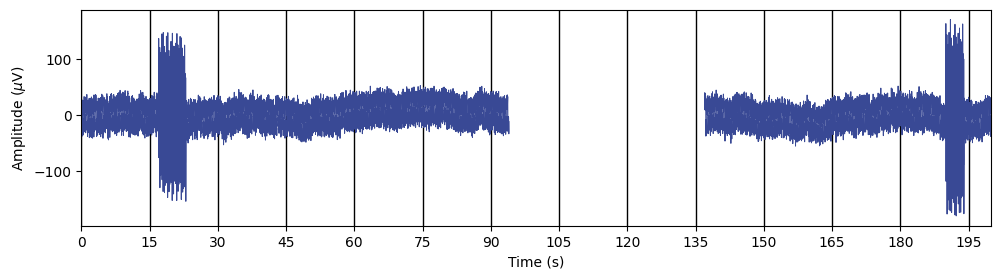

In [242]:
fig1 = make_fig(1)

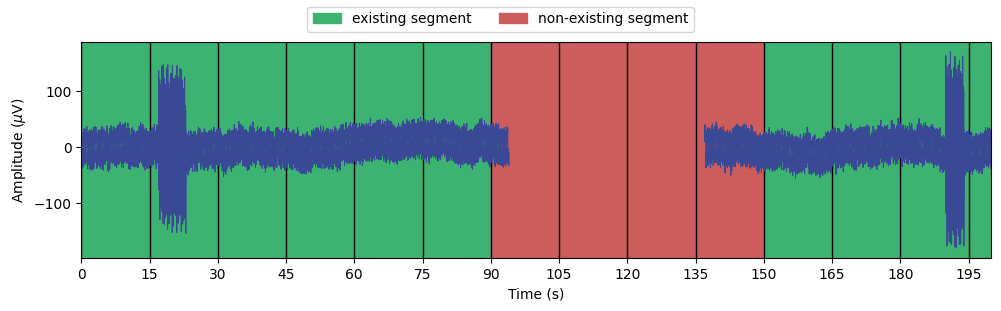

In [243]:
fig2 = make_fig(2)

In [244]:
# Save figures
for i, figure in enumerate([fig0, fig1, fig2]):
    path = Path(f"~/Downloads/segments_figure{i}.png").expanduser()
    print(f"Saving figure to {path}")
    figure.savefig(path, dpi=300)

Saving figure to /Users/julian/Downloads/segments_figure0.png
Saving figure to /Users/julian/Downloads/segments_figure1.png
Saving figure to /Users/julian/Downloads/segments_figure2.png
